# Visual Feature Extraction — Verification & Visualization (IEMOCAP)

Complete walkthrough of the unified face-crop pipeline used in `extract_video_iemocap.ipynb`.

**Pipeline overview:**
1. **Frame sampling** — 2 fps, max 60 frames per clip
2. **RetinaFace detection** — face bounding box + crop, once per frame
3. **Temporal segmentation** — beginning / middle / end (3 crops each)
4. **CLIP ViT-L/14** — face crops → L2-normalised `(3, 768)`
5. **SigLIP 2 so400m-patch14-384** — face crops → raw `(3, 1152)`
6. **OpenFace AU** — face crops → `(3, 8)` AU intensity

All three models receive the **same RetinaFace crop** — same spatial region, no redundant detection.
IEMOCAP videos are speaker-cropped — single frontal face per clip.
Expected face coverage: **>95%** (clean setup).

In [1]:
import os
import cv2
import tempfile
import torch
import numpy as np
import pandas as pd
import clip
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, AutoModel as HFAutoModel
from openface.face_detection import FaceDetector
from openface.multitask_model import MultitaskPredictor

PROJECT_ROOT = Path("/mnt/Work/ML/Thesis/BMVC/Hopeful")
DATA_ROOT    = PROJECT_ROOT / "Dataset/Processed/IEMOCAP"
FEATURES_DIR = DATA_ROOT / "features"
OF3_WEIGHTS  = Path.home() / ".cache" / "openface"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

FRAME_SAMPLE_FPS  = 2
MAX_FRAMES        = 60
N_FRAMES_PER_SEG  = 3
AU_CONF_THRESHOLD = 0.5

# Change to inspect a different clip
SAMPLE_UTT = ""  # auto-set in next cell

Device: cuda
GPU   : NVIDIA GeForce RTX 3060


In [3]:
labels = pd.read_csv(DATA_ROOT / "labels.csv")
if not SAMPLE_UTT:
    SAMPLE_UTT = labels.iloc[0]["utt_id"]
row      = labels[labels["utt_id"] == SAMPLE_UTT].iloc[0]
vid_path = DATA_ROOT / row["video_path"]

cap      = cv2.VideoCapture(str(vid_path))
src_fps  = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Clip      : {SAMPLE_UTT}")
print(f"Emotion   : {row['emotion']}")
print(f"Duration  : {n_frames/src_fps:.2f}s  ({n_frames} frames @ {src_fps:.1f} fps)")
print(f"Resolution: {width}x{height}")

Clip      : Ses01F_impro01_F000
Emotion   : neu
Duration  : 1.94s  (58 frames @ 30.0 fps)
Resolution: 360x480


## Step 1 — Frame Sampling

Sample one frame every `src_fps / 2` source frames → ~2 samples per second.  
Cap at 60 frames to mirror the 30s audio truncation guard.

**Why 2 fps?**
- Short clips (1–5s) → 2–10 sampled frames; enough to cover expression changes
- Avoids redundant near-identical frames (adjacent frames at 25fps are nearly identical)
- Memory-efficient: keeps GPU batch size small for CLIP/SigLIP2

Each sampled frame shown below with its timestamp.

Source fps    : 30.0
Sample interval: every 15 source frames → ~2.0 fps effective
Frames sampled : 4 / 58 total
Timestamps     : [0.0, 0.5, 1.0, 1.5]


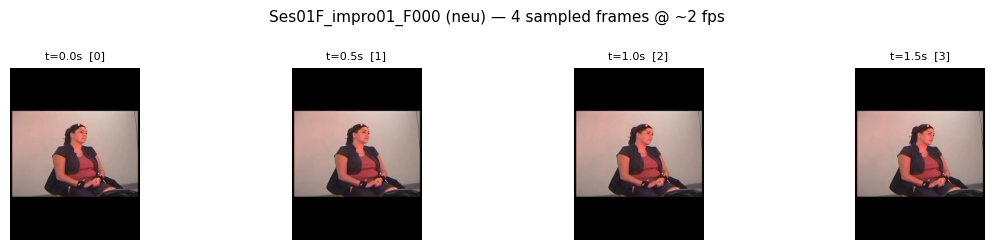

In [5]:
def sample_frames(video_path, fps=FRAME_SAMPLE_FPS, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return [], [], 0
    src_fps_  = cap.get(cv2.CAP_PROP_FPS) or 25.0
    interval  = max(1, int(round(src_fps_ / fps)))
    frames, indices = [], []
    idx = 0
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret or frame is None or frame.size == 0:
            break
        if idx % interval == 0:
            frames.append(frame)
            indices.append(idx)
        idx += 1
    cap.release()
    return frames, indices, interval

def temporal_segments(items, n=N_FRAMES_PER_SEG):
    total  = len(items)
    mid    = total // 2
    half_n = n // 2
    beg     = items[:n]
    mid_seg = items[max(0, mid - half_n): max(0, mid - half_n) + n]
    end     = items[max(0, total - n):]
    return beg, mid_seg, end

frames, frame_indices, interval = sample_frames(vid_path)
print(f"Source fps    : {src_fps:.1f}")
print(f"Sample interval: every {interval} source frames → ~{src_fps/interval:.1f} fps effective")
print(f"Frames sampled : {len(frames)} / {n_frames} total")
print(f"Timestamps     : {[round(i/src_fps, 2) for i in frame_indices]}")

n = len(frames)
cols = min(n, 6); rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.5))
axes = np.array(axes).flatten()
for i, (f, fi) in enumerate(zip(frames, frame_indices)):
    axes[i].imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"t={fi/src_fps:.1f}s  [{i}]", fontsize=8)
    axes[i].axis('off')
for j in range(i + 1, len(axes)): axes[j].axis('off')
fig.suptitle(f"{SAMPLE_UTT} ({row['emotion']}) — {len(frames)} sampled frames @ ~2 fps", fontsize=11)
plt.tight_layout(); plt.show()

## Step 2 — RetinaFace Face Detection

RetinaFace MobileNet detects a face bounding box in each sampled frame.  
Each frame is saved to a temp `.jpg` because `FaceDetector.get_face()` needs a file path.

**Output per frame:**
- `crop` — BGR numpy array of the detected face region (variable size)
- `dets` — `[x1, y1, x2, y2, confidence]` for each detected face

**Skipped when:**
- No face detected (confidence below `vis_threshold=0.5`)
- Bounding box is degenerate (`x2 ≤ x1` or `y2 ≤ y1`) → `crop.size == 0`

Green box = face found. Red label = no face.

Loading pretrained model from /home/jubaer/.cache/openface/Alignment_RetinaFace.pth
remove prefix 'module.'
Missing keys:0
Unused checkpoint keys:0
Used keys:300
RetinaFace loaded
Face detected : 4 / 4 frames  (100%)


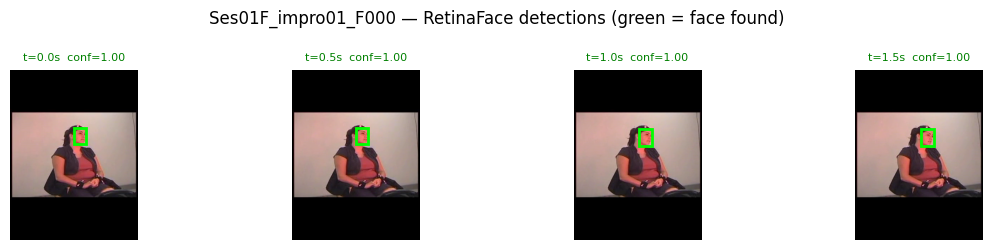

In [6]:
of3_face = FaceDetector(
    model_path=str(OF3_WEIGHTS / "Alignment_RetinaFace.pth"),
    device=str(DEVICE),
    vis_threshold=AU_CONF_THRESHOLD,
)
print("RetinaFace loaded")

crops_per_frame = []
dets_per_frame  = []

with tempfile.TemporaryDirectory() as tmpdir:
    for i, frame in enumerate(frames):
        fpath = os.path.join(tmpdir, f"f{i:04d}.jpg")
        cv2.imwrite(fpath, frame)
        crop, dets = of3_face.get_face(fpath)
        dets_per_frame.append(dets)
        crops_per_frame.append(crop if (crop is not None and crop.size > 0) else None)

valid_crops = [c for c in crops_per_frame if c is not None]
idx_valid   = [i for i, c in enumerate(crops_per_frame) if c is not None]
n_det = len(valid_crops)
print(f"Face detected : {n_det} / {len(frames)} frames  ({n_det/max(len(frames),1)*100:.0f}%)")

# Frames with bounding boxes
n = len(frames)
cols = min(n, 6); rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.5))
axes = np.array(axes).flatten()
for i, (frame, dets) in enumerate(zip(frames, dets_per_frame)):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    axes[i].imshow(rgb)
    t = round(frame_indices[i] / src_fps, 1)
    if dets is not None and len(dets) > 0:
        x1, y1, x2, y2, conf = dets[0][:5]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        axes[i].add_patch(rect)
        axes[i].set_title(f"t={t}s  conf={conf:.2f}", fontsize=8, color="green")
    else:
        axes[i].set_title(f"t={t}s  NO FACE", fontsize=8, color="red")
    axes[i].axis("off")
for j in range(i + 1, len(axes)): axes[j].axis("off")
fig.suptitle(f"{SAMPLE_UTT} — RetinaFace detections (green = face found)")
plt.tight_layout(); plt.show()

## Step 3 — Face Crops

The crop is the **only input** to CLIP, SigLIP 2, and OpenFace AU.

**Why crop instead of full frame?**
- IEMOCAP videos are speaker-cropped but still include shoulders/background
- Face crop focuses the model on the relevant region
- RetinaFace runs once; crops reused for all three models (no redundant detection)

Crop dimensions vary per frame (RetinaFace returns the bbox region as-is).

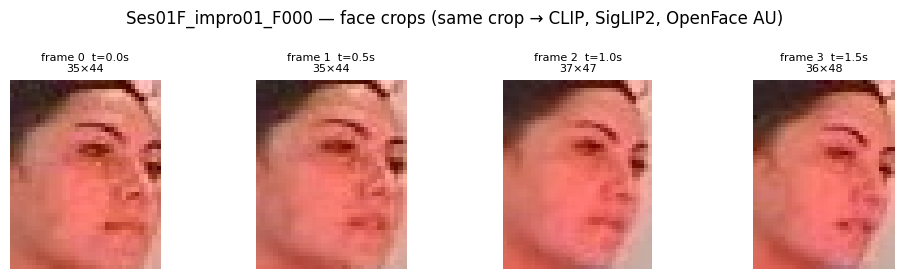

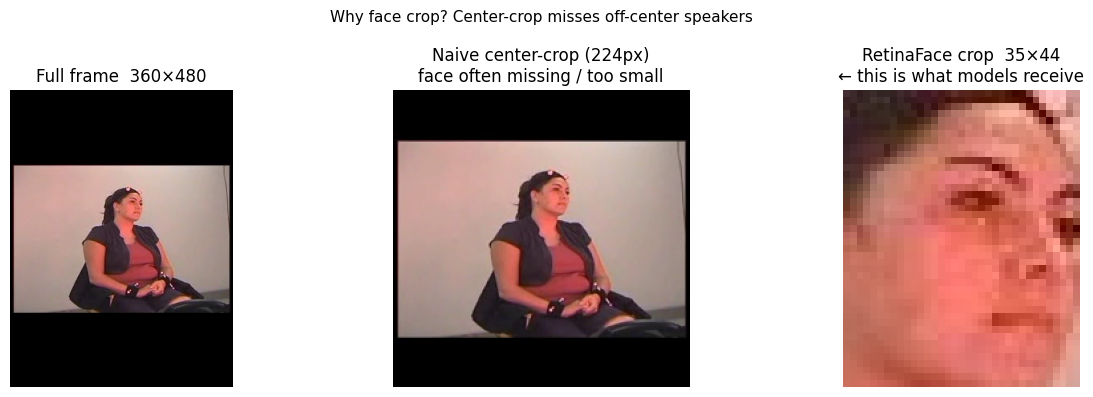

In [7]:
if valid_crops:
    n_show = min(len(valid_crops), 12)
    cols2 = min(n_show, 6); rows2 = (n_show + cols2 - 1) // cols2
    fig, axes = plt.subplots(rows2, cols2, figsize=(cols2 * 2.5, rows2 * 2.8))
    axes = np.array(axes).flatten()
    for k, (ci, crop) in enumerate(list(zip(idx_valid, valid_crops))[:n_show]):
        axes[k].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[k].set_title(
            f"frame {ci}  t={round(frame_indices[ci]/src_fps,1)}s\n"
            f"{crop.shape[1]}\u00d7{crop.shape[0]}", fontsize=8)
        axes[k].axis("off")
    for j in range(k + 1, len(axes)): axes[j].axis("off")
    fig.suptitle(f"{SAMPLE_UTT} — face crops (same crop → CLIP, SigLIP2, OpenFace AU)")
    plt.tight_layout(); plt.show()

    # Side-by-side: full frame vs CLIP naive center-crop vs face crop
    first_crop      = valid_crops[0]
    first_frame_rgb = cv2.cvtColor(frames[idx_valid[0]], cv2.COLOR_BGR2RGB)
    first_crop_rgb  = cv2.cvtColor(first_crop, cv2.COLOR_BGR2RGB)
    h_, w_ = first_frame_rgb.shape[:2]
    sz     = min(h_, w_)
    top_   = (h_ - sz) // 2; left_ = (w_ - sz) // 2
    center_crop = Image.fromarray(first_frame_rgb).crop(
        (left_, top_, left_ + sz, top_ + sz)).resize((224, 224))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(first_frame_rgb)
    axes[0].set_title(f"Full frame  {w_}\u00d7{h_}")
    axes[1].imshow(center_crop)
    axes[1].set_title("Naive center-crop (224px)\nface often missing / too small")
    axes[2].imshow(first_crop_rgb)
    axes[2].set_title(
        f"RetinaFace crop  {first_crop.shape[1]}\u00d7{first_crop.shape[0]}\n"
        "← this is what models receive")
    for ax in axes: ax.axis("off")
    fig.suptitle("Why face crop? Center-crop misses off-center speakers", fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print("No face detected in any frame of {SAMPLE_UTT} — try a different clip")

## Step 4 — Temporal Segmentation

Valid face crops (chronological order) split into 3 groups:
- **Beginning** — first 3 crops  
- **Middle** — 3 crops centred at the midpoint  
- **End** — last 3 crops  

**Why 3 groups instead of single mean-pool?**
- Expressions have temporal structure: onset → apex → offset
- Single mean-pool discards this ordering
- 3-segment pooling captures the arc at low cost
- Consistent with audio (WavLM: first/mid/last segments) and text (CLS/tok/SEP regions)

Each group mean-pooled → `(dim,)` per group → stack → `(3, dim)` for all three models.

Total valid crops : 4
  Beginning : 3 crops  (frame idx: [0, 15, 30])
  Middle    : 3 crops  (frame idx: [15, 30, 45])
  End       : 3 crops  (frame idx: [15, 30, 45])


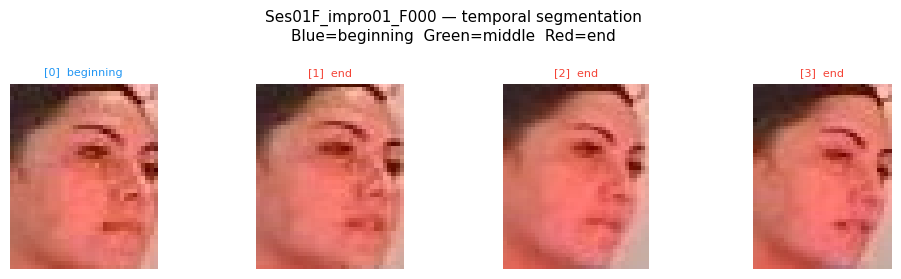

In [8]:
beg_crops, mid_crops, end_crops = temporal_segments(valid_crops)
beg_idx_s, mid_idx_s, end_idx_s = temporal_segments(idx_valid)

print(f"Total valid crops : {len(valid_crops)}")
print(f"  Beginning : {len(beg_crops)} crops  (frame idx: {[frame_indices[i] for i in beg_idx_s]})")
print(f"  Middle    : {len(mid_crops)} crops  (frame idx: {[frame_indices[i] for i in mid_idx_s]})")
print(f"  End       : {len(end_crops)} crops  (frame idx: {[frame_indices[i] for i in end_idx_s]})")

seg_color_map = {}
for ci in beg_idx_s: seg_color_map[ci] = ("beginning", "#2196F3")
for ci in mid_idx_s: seg_color_map[ci] = ("middle",    "#4CAF50")
for ci in end_idx_s: seg_color_map[ci] = ("end",       "#F44336")

n_show = min(len(valid_crops), 12)
cols3 = min(n_show, 6); rows3 = (n_show + cols3 - 1) // cols3
fig, axes = plt.subplots(rows3, cols3, figsize=(cols3 * 2.5, rows3 * 2.8))
axes = np.array(axes).flatten()
for k, (ci, crop) in enumerate(list(zip(idx_valid, valid_crops))[:n_show]):
    seg_name, seg_col = seg_color_map.get(ci, ("—", "gray"))
    axes[k].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    for spine in axes[k].spines.values():
        spine.set_edgecolor(seg_col); spine.set_linewidth(4)
    axes[k].set_title(f"[{ci}]  {seg_name}", fontsize=8, color=seg_col)
    axes[k].axis("off")
for j in range(k + 1, len(axes)): axes[j].axis("off")
seg_names = ["beginning", "middle", "end"]
fig.suptitle(f"{SAMPLE_UTT} — temporal segmentation\n"
             "Blue=beginning  Green=middle  Red=end", fontsize=11)
plt.tight_layout(); plt.show()

## Step 5 — CLIP ViT-L/14 Feature Extraction

For each temporal segment's crops:
1. Convert BGR face crops → RGB PIL images
2. Apply CLIP preprocessing: resize + center-crop to **224×224**, ImageNet normalisation
3. `clip_model.encode_image()` → raw 768-dim embedding per crop
4. **L2-normalise** each embedding (CLIP uses cosine similarity loss)
5. Mean-pool over segment → `(768,)` per segment
6. Stack 3 segments → `(3, 768)`

Result: norms ≈ 1.0 because mean of L2-normalised vectors stays near unit sphere.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7520971..1.9303361].


CLIP ViT-L/14  output_dim=768


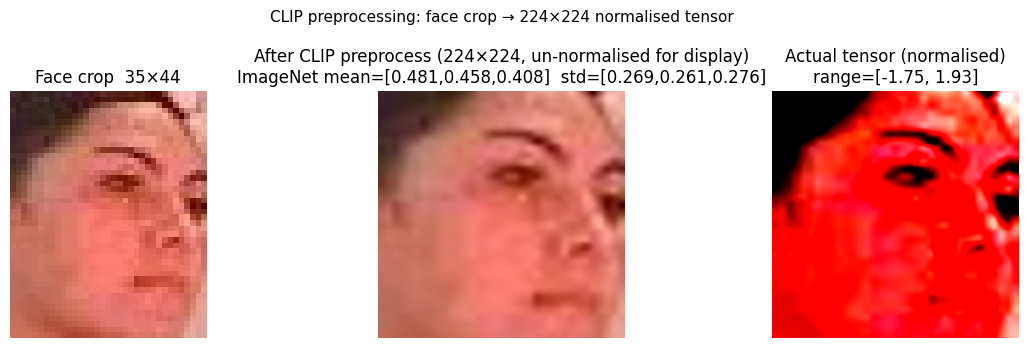


CLIP output shape: (3, 768)
  beginning   : norm=0.9863  min=-0.4876  max=0.5190
  middle      : norm=0.9900  min=-0.4905  max=0.5217
  end         : norm=0.9900  min=-0.4905  max=0.5217
Note: norms ≈ 1.0 — each frame L2-normalised before mean-pooling.


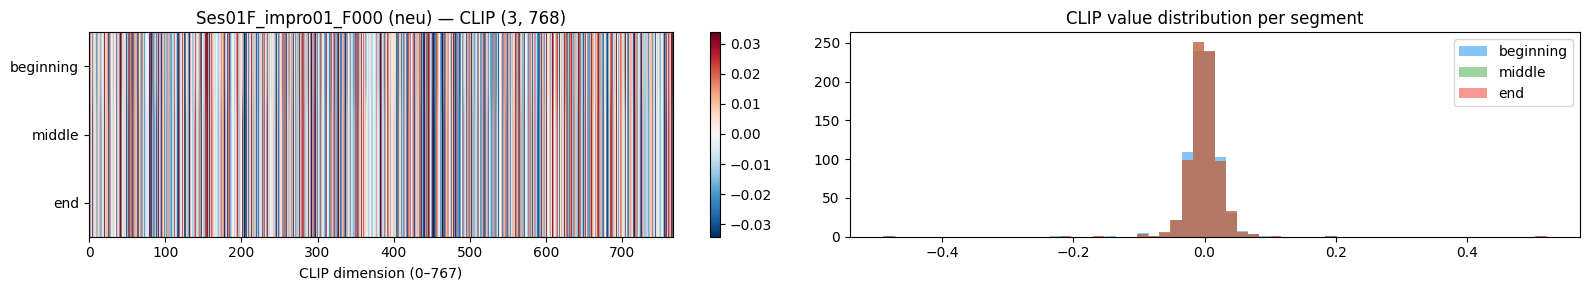

In [10]:
clip_model, clip_preprocess = clip.load("ViT-L/14", device=DEVICE)
clip_model.eval()
for p in clip_model.parameters(): p.requires_grad_(False)
CLIP_DIM = clip_model.visual.output_dim
print(f"CLIP ViT-L/14  output_dim={CLIP_DIM}")

# Show preprocessing on first crop
if valid_crops:
    sample_pil_clip = Image.fromarray(cv2.cvtColor(valid_crops[0], cv2.COLOR_BGR2RGB))
    t_clip = clip_preprocess(sample_pil_clip)  # (3, 224, 224)
    im_mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3,1,1)
    im_std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3,1,1)
    unnorm_clip = (t_clip * im_std + im_mean).clamp(0,1).permute(1,2,0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].imshow(cv2.cvtColor(valid_crops[0], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Face crop  {valid_crops[0].shape[1]}\u00d7{valid_crops[0].shape[0]}")
    axes[1].imshow(unnorm_clip)
    axes[1].set_title("After CLIP preprocess (224\u00d7224, un-normalised for display)\n"
                      "ImageNet mean=[0.481,0.458,0.408]  std=[0.269,0.261,0.276]")
    axes[2].imshow(t_clip.permute(1,2,0).numpy(), vmin=-2.5, vmax=2.5, cmap="RdBu_r")
    axes[2].set_title(f"Actual tensor (normalised)\n"
                      f"range=[{t_clip.min():.2f}, {t_clip.max():.2f}]")
    for ax in axes: ax.axis("off")
    fig.suptitle("CLIP preprocessing: face crop \u2192 224\u00d7224 normalised tensor", fontsize=11)
    plt.tight_layout(); plt.show()

def encode_clip(crops):
    """Matches extract_video_iemocap.ipynb encode_clip exactly."""
    if not crops:
        return np.zeros((3, CLIP_DIM), dtype=np.float32)
    vecs = []
    for seg in temporal_segments(crops):
        if not seg:
            vecs.append(np.zeros(CLIP_DIM, dtype=np.float32)); continue
        pil = [Image.fromarray(cv2.cvtColor(c, cv2.COLOR_BGR2RGB)) for c in seg]
        t   = torch.stack([clip_preprocess(p) for p in pil]).to(DEVICE)
        with torch.no_grad():
            e = clip_model.encode_image(t).float()
            e = e / e.norm(dim=-1, keepdim=True)
        vecs.append(e.cpu().numpy().mean(axis=0))
    return np.stack(vecs)

clip_feat = encode_clip(valid_crops)
print(f"\nCLIP output shape: {clip_feat.shape}")
for i, name in enumerate(seg_names):
    v = clip_feat[i]
    print(f"  {name:12s}: norm={np.linalg.norm(v):.4f}  min={v.min():.4f}  max={v.max():.4f}")
print("Note: norms \u2248 1.0 \u2014 each frame L2-normalised before mean-pooling.")

fig, axes = plt.subplots(1, 2, figsize=(16, 3))
im = axes[0].imshow(clip_feat, aspect="auto", cmap="RdBu_r",
                    vmin=np.percentile(clip_feat,5), vmax=np.percentile(clip_feat,95))
axes[0].set_yticks([0,1,2]); axes[0].set_yticklabels(seg_names)
axes[0].set_xlabel("CLIP dimension (0\u2013767)")
axes[0].set_title(f"{SAMPLE_UTT} ({row['emotion']}) \u2014 CLIP (3, {CLIP_DIM})")
plt.colorbar(im, ax=axes[0])
for i, (name, color) in enumerate(zip(seg_names, ["#2196F3","#4CAF50","#F44336"])):
    axes[1].hist(clip_feat[i], bins=60, alpha=0.55, label=name, color=color)
axes[1].set_title("CLIP value distribution per segment"); axes[1].legend()
plt.tight_layout(); plt.show()

## Step 6 — SigLIP 2 Feature Extraction

For each temporal segment's crops:
1. Convert BGR face crops → RGB PIL images
2. `AutoProcessor` resize + center-crop to **384×384**, SigLIP 2 normalisation
3. `siglip2_model.vision_model(**inputs)` → `pooler_output`
4. **No L2-normalisation** — SigLIP 2 uses sigmoid loss; outputs are not unit vectors
5. Mean-pool over segment → `(1152,)` per segment
6. Stack 3 segments → `(3, 1152)`

| | CLIP | SigLIP 2 |
|---|---|---|
| Input size | 224×224 | **384×384** |
| Output dim | 768 | **1152** |
| Output normalised | Yes (L2) | **No** |
| Training loss | Softmax contrastive | **Sigmoid** |
| Training data | WIT 400M | WebLI 10B+ |

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


SigLIP 2 so400m  output_dim=1152


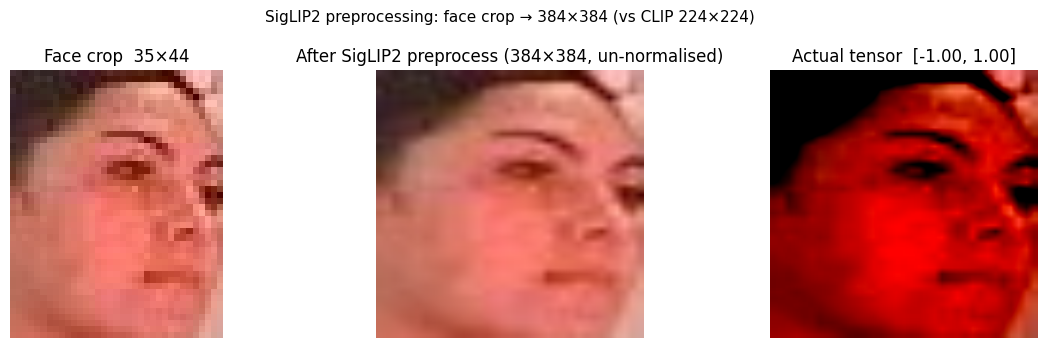


SigLIP2 output shape: (3, 1152)
  beginning   : norm=17.7034  min=-9.4417  max=2.2688
  middle      : norm=17.5900  min=-9.3486  max=2.2971
  end         : norm=17.5900  min=-9.3486  max=2.2971
Note: norms NOT ≈ 1.0 — SigLIP2 uses sigmoid loss, output un-normalised.


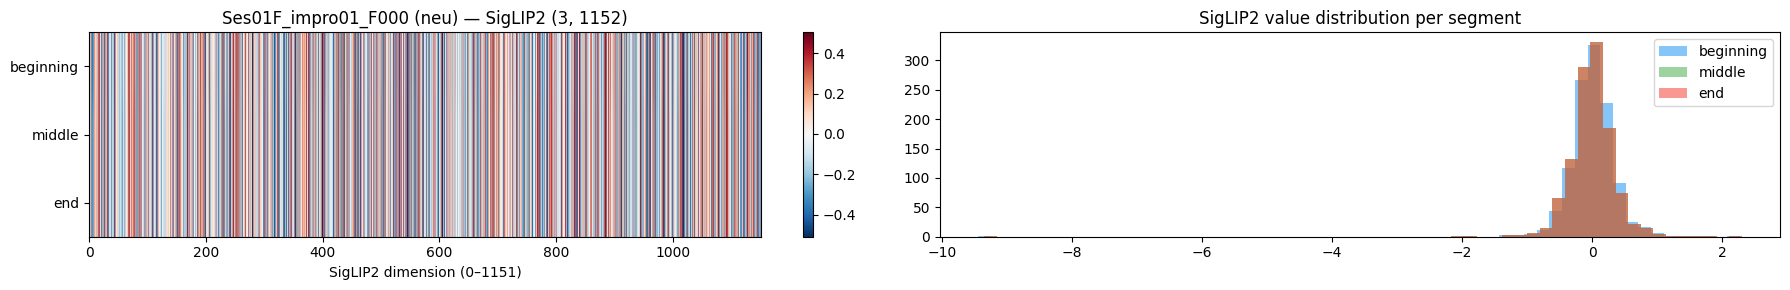

In [13]:
siglip2_proc  = AutoProcessor.from_pretrained("google/siglip2-so400m-patch14-384")
siglip2_model = HFAutoModel.from_pretrained("google/siglip2-so400m-patch14-384")
siglip2_model.eval()
for p in siglip2_model.parameters(): p.requires_grad_(False)
siglip2_model = siglip2_model.to(DEVICE)
SIGLIP2_DIM   = siglip2_model.config.vision_config.hidden_size
print(f"SigLIP 2 so400m  output_dim={SIGLIP2_DIM}")

# Preprocessing viz
if valid_crops:
    inputs_s = siglip2_proc(
        images=[Image.fromarray(cv2.cvtColor(valid_crops[0], cv2.COLOR_BGR2RGB))],
        return_tensors="pt"
    )
    t_sig = inputs_s["pixel_values"][0]
    try:
        ip       = siglip2_proc.image_processor
        s_mean   = torch.tensor(ip.image_mean).view(3,1,1)
        s_std    = torch.tensor(ip.image_std).view(3,1,1)
        unnorm_s = (t_sig.cpu() * s_std + s_mean).clamp(0,1).permute(1,2,0).numpy()
    except:
        unnorm_s = None
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].imshow(cv2.cvtColor(valid_crops[0], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Face crop  {valid_crops[0].shape[1]}\u00d7{valid_crops[0].shape[0]}")
    if unnorm_s is not None:
        axes[1].imshow(unnorm_s)
        axes[1].set_title("After SigLIP2 preprocess (384\u00d7384, un-normalised)")
    axes[2].imshow(t_sig.cpu().permute(1,2,0).numpy(), vmin=-3, vmax=3, cmap="RdBu_r")
    axes[2].set_title(f"Actual tensor  [{t_sig.min():.2f}, {t_sig.max():.2f}]")
    for ax in axes: ax.axis("off")
    fig.suptitle("SigLIP2 preprocessing: face crop → 384\u00d7384 (vs CLIP 224\u00d7224)",
                 fontsize=11)
    plt.tight_layout(); plt.show()

def encode_siglip2(crops):
    """Matches extract_video_iemocap.ipynb encode_siglip2 exactly."""
    if not crops:
        return np.zeros((3, SIGLIP2_DIM), dtype=np.float32)
    vecs = []
    for seg in temporal_segments(crops):
        if not seg:
            vecs.append(np.zeros(SIGLIP2_DIM, dtype=np.float32)); continue
        pil    = [Image.fromarray(cv2.cvtColor(c, cv2.COLOR_BGR2RGB)) for c in seg]
        inputs = siglip2_proc(images=pil, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = siglip2_model.vision_model(**inputs)
        vecs.append(out.pooler_output.cpu().float().numpy().mean(axis=0))
    return np.stack(vecs)

sig_feat = encode_siglip2(valid_crops)
print(f"\nSigLIP2 output shape: {sig_feat.shape}")
for i, name in enumerate(seg_names):
    v = sig_feat[i]
    print(f"  {name:12s}: norm={np.linalg.norm(v):.4f}  min={v.min():.4f}  max={v.max():.4f}")
print("Note: norms NOT ≈ 1.0 — SigLIP2 uses sigmoid loss, output un-normalised.")

fig, axes = plt.subplots(1, 2, figsize=(18, 3))
im = axes[0].imshow(sig_feat, aspect="auto", cmap="RdBu_r",
                    vmin=np.percentile(sig_feat,5), vmax=np.percentile(sig_feat,95))
axes[0].set_yticks([0,1,2]); axes[0].set_yticklabels(seg_names)
axes[0].set_xlabel("SigLIP2 dimension (0–1151)")
axes[0].set_title(f"{SAMPLE_UTT} ({row['emotion']}) — SigLIP2 (3, {SIGLIP2_DIM})")
plt.colorbar(im, ax=axes[0])
for i, (name, color) in enumerate(zip(seg_names, ["#2196F3","#4CAF50","#F44336"])):
    axes[1].hist(sig_feat[i], bins=60, alpha=0.55, label=name, color=color)
axes[1].set_title("SigLIP2 value distribution per segment"); axes[1].legend()
plt.tight_layout(); plt.show()

## Step 7 — OpenFace AU Feature Extraction

For each temporal segment's crops:
1. `MultitaskPredictor.predict(crop)` → `(emotion_logits, gaze, au_intensities)`
2. Take only `au_intensities` → `(8,)` per crop
3. Mean-pool over segment crops → `(8,)` per segment
4. Stack 3 segments → `(3, 8)`

**Why only AU output?**  
We use text + audio for emotion classification — the MTL emotion logits are not needed.  
The AU vector captures **face-specific muscle activation** that text/audio cannot replicate.  
In SC-VAH's M6, AU vectors condition hyperedge weights: the graph structure adapts
based on which facial muscles are active per utterance.

**AU intensity scale:**  
Approximately [0, 1] — GNN-head cosine similarity output from the MTL backbone.

/mnt/Work/Environments/Ubuntu/Conda/envs/hopeful/lib/python3.10/site-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


Loading multitask model from /home/jubaer/.cache/openface/MTL_backbone.pth...
OpenFace MTL  AU_DIM=8

=== All MTL outputs for first crop ===
emotion logits shape: torch.Size([1, 8])
  Contempt  : 0.217  █████
  Sad       : 0.207  █████
  Neutral   : 0.146  ███
  Disgust   : 0.133  ███
  Happy     : 0.097  ██
  Fear      : 0.092  ██
  Surprise  : 0.070  █
  Angry     : 0.038  

gaze: pitch=-9.8°  yaw=7.8°

AU intensities (8D)  ← WHAT WE SAVE:
  [0.3994 0.2942 0.0023 0.     0.0066 0.0009 0.3379 0.0197]

OpenFace AU output shape: (3, 8)
  beginning   : [0.4243 0.2243 0.098  0.0247 0.2753 0.0013 0.3653 0.0476]
  middle      : [0.4699 0.1313 0.1067 0.036  0.3543 0.001  0.3454 0.0773]
  end         : [0.4699 0.1313 0.1067 0.036  0.3543 0.001  0.3454 0.0773]


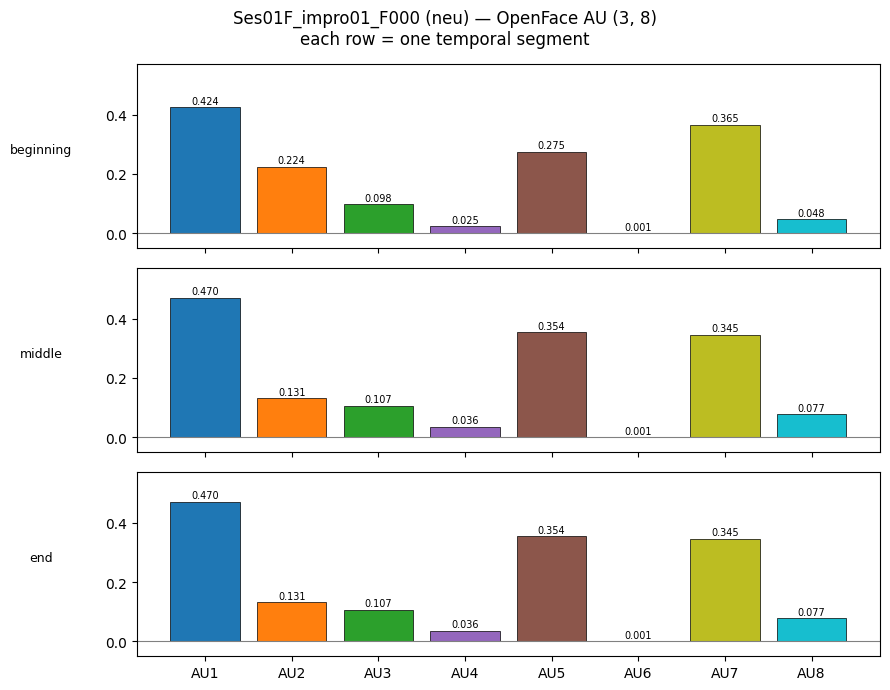

In [14]:
of3_pred = MultitaskPredictor(
    model_path=str(OF3_WEIGHTS / "MTL_backbone.pth"),
    device=str(DEVICE),
)
AU_DIM = of3_pred.model.au_regressor.num_classes
print(f"OpenFace MTL  AU_DIM={AU_DIM}")

# Inspect all three MTL outputs for first valid crop
if valid_crops:
    emo_out, gaze_out, au_out = of3_pred.predict(valid_crops[0])
    print("\n=== All MTL outputs for first crop ===")
    emo_probs  = torch.softmax(emo_out, -1).cpu().numpy().flatten()
    emo_names  = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Angry","Contempt"]
    print(f"emotion logits shape: {emo_out.shape}")
    for name, prob in sorted(zip(emo_names, emo_probs), key=lambda x: -x[1]):
        print(f"  {name:10s}: {prob:.3f}  {chr(9608)*int(prob*25)}")
    gaze = gaze_out.cpu().numpy().flatten()
    print(f"\ngaze: pitch={np.degrees(gaze[0]):.1f}\u00b0  yaw={np.degrees(gaze[1]):.1f}\u00b0")
    au_vals = au_out.cpu().numpy().flatten()
    print(f"\nAU intensities ({AU_DIM}D)  \u2190 WHAT WE SAVE:")
    print(f"  {au_vals.round(4)}")

def encode_au(crops):
    """Matches extract_video_iemocap.ipynb encode_au exactly."""
    if not crops:
        return np.zeros((3, AU_DIM), dtype=np.float32)
    vecs = []
    for seg in temporal_segments(crops):
        if not seg:
            vecs.append(np.zeros(AU_DIM, dtype=np.float32)); continue
        aus = []
        for crop in seg:
            _, _, au_out_ = of3_pred.predict(crop)
            aus.append(au_out_.cpu().float().numpy().flatten())
        vecs.append(np.stack(aus).mean(axis=0))
    return np.stack(vecs)

au_feat = encode_au(valid_crops)
print(f"\nOpenFace AU output shape: {au_feat.shape}")
for i, name in enumerate(seg_names):
    print(f"  {name:12s}: {np.round(au_feat[i], 4)}")

colors_au = plt.cm.tab10(np.linspace(0, 1, AU_DIM))
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for row_i, (ax, seg_name) in enumerate(zip(axes, seg_names)):
    bars = ax.bar(range(AU_DIM), au_feat[row_i], color=colors_au,
                  edgecolor="black", linewidth=0.5)
    ax.set_ylabel(seg_name, fontsize=9, rotation=0, labelpad=46)
    ax.set_ylim(-0.05, max(float(au_feat.max()) + 0.1, 0.3))
    ax.axhline(0, color="gray", linewidth=0.8)
    for bar, val in zip(bars, au_feat[row_i]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
axes[-1].set_xticks(range(AU_DIM))
axes[-1].set_xticklabels([f"AU{i+1}" for i in range(AU_DIM)])
fig.suptitle(f"{SAMPLE_UTT} ({row['emotion']}) — OpenFace AU (3, 8)\neach row = one temporal segment")
plt.tight_layout(); plt.show()

## Step 8 — Verify Against Saved `.pt` Files

Compare the features computed above against the pre-saved `.pt` files from
`extract_video_iemocap.ipynb`.

**Expected result:** `MATCH ✓` with max diff ≈ 0 (same model weights, same video, same logic).

**`MISMATCH`** means the saved file used a different pipeline version:
- Old approach: full-frame CLIP/SigLIP2, flat `(8,)` AU → shapes differ or values differ
- Fix: run the delete cell then extraction loop in `extract_video_iemocap.ipynb`

In [15]:
files = {
    "CLIP     (3,768) ": (FEATURES_DIR / "video_clip_temporal.pt", clip_feat),
    "SigLIP2  (3,1152)": (FEATURES_DIR / "video_siglip2_temporal.pt",  sig_feat),
    "AU       (3,8)   ": (FEATURES_DIR / "video_openface_au.pt",   au_feat),
}

print(f"=== Verification: {SAMPLE_UTT} ({row['emotion']})")
print()
for label, (pt_path, computed) in files.items():
    if not pt_path.exists():
        print(f"  {label}: FILE MISSING — run extract_video_iemocap.ipynb"); continue
    saved = torch.load(pt_path, weights_only=False)
    if SAMPLE_UTT not in saved:
        print(f"  {label}: KEY {SAMPLE_UTT} MISSING in .pt"); continue
    stored = np.array(saved[SAMPLE_UTT])
    if stored.shape != computed.shape:
        print(f"  {label}: SHAPE MISMATCH stored={stored.shape} vs computed={computed.shape}")
        print(f"    Old pipeline. Re-run extract_video_iemocap.ipynb.")
        continue
    diff = np.abs(stored - computed)
    status = "MATCH \u2713" if diff.max() < 1e-4 else f"MISMATCH (max_diff={diff.max():.2e})"
    print(f"  {label}: {status}  (file has {len(saved)} entries)")
    if diff.max() >= 1e-4:
        print(f"    Re-run extract_video_iemocap.ipynb (delete old .pt files first).")

=== Verification: Ses01F_impro01_F000 (neu)

  CLIP     (3,768) : MATCH ✓  (file has 10039 entries)
  SigLIP2  (3,1152): MATCH ✓  (file has 10039 entries)
  AU       (3,8)   : MATCH ✓  (file has 10039 entries)


## Step 9 — Full File Sanity Check

Check all `.pt` files for:
- File exists
- Expected utterance count
- Shape `(3, dim)` per utterance
- No NaN or Inf values
- Face coverage (utterances with non-zero features)

In [16]:
print("=== Full File Sanity: IEMOCAP ===\n")
exp_count = 10039
checks = [
    ("video_clip_temporal",    (3, CLIP_DIM)),
    ("video_siglip2_temporal", (3, SIGLIP2_DIM)),
    ("video_openface_au",      (3, AU_DIM)),
]
for tag, exp_shape in checks:
    pt = FEATURES_DIR / f"{tag}.pt"
    if not pt.exists():
        print(f"{tag}: MISSING"); continue
    d   = torch.load(pt, weights_only=False)
    arr = np.stack([np.array(v) for v in d.values()])
    shape  = np.array(next(iter(d.values()))).shape
    n_zero = (np.abs(arr).sum(axis=(1,2)) < 1e-6).sum()
    n_ok   = len(d) - n_zero
    cnt_ok = "\u2713" if len(d) >= exp_count - 5 else f"\u2717 (expected {exp_count})"
    shp_ok = "\u2713" if shape == exp_shape else f"\u2717 expected {exp_shape}"
    nan_ok = "\u2713" if not np.isnan(arr).any() else "\u2717 NaN!"
    inf_ok = "\u2713" if not np.isinf(arr).any() else "\u2717 Inf!"
    print(f"{tag}: count={len(d)} {cnt_ok}  shape={shape} {shp_ok}  "
          f"NaN={nan_ok}  Inf={inf_ok}  coverage={n_ok}/{len(d)} ({n_ok/max(len(d),1)*100:.1f}%)")
print()


=== Full File Sanity: IEMOCAP ===

video_clip_temporal: count=10039 ✓  shape=(3, 768) ✓  NaN=✓  Inf=✓  coverage=9960/10039 (99.2%)
video_siglip2_temporal: count=10039 ✓  shape=(3, 1152) ✓  NaN=✓  Inf=✓  coverage=9960/10039 (99.2%)
video_openface_au: count=10039 ✓  shape=(3, 8) ✓  NaN=✓  Inf=✓  coverage=9960/10039 (99.2%)

